In [ ]:
print('init')

In [ ]:
import io, os, re, sys, warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
import ipywidgets as widgets

from scipy.signal import lfilter
from IPython.display import display, clear_output

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model import TCN, TransformerMoment

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## 1 · Configuration

In [ ]:
OPENSIM_ROOT = Path("/home/metamobility3/Jinwoo/AB03_Ilseung")
NPZ_ROOT = PROJECT_ROOT

CHECKPOINT_HIP = PROJECT_ROOT / "runs/0510_ik_id_hip_no_stair_epic_only/best_model.pt"
CHECKPOINT_KNEE = PROJECT_ROOT / "runs/0510_ik_id_knee_no_stair_epic_only/best_model.pt"

HIP_CFG_PATH = PROJECT_ROOT / "hip-exo-ctrl-V2/cfg/final.yaml"
KNEE_CFG_PATH = PROJECT_ROOT / "knee-exo-ctrl/cfg/final.yaml"

SUBJECT_MASS_KG = 84.4
MOCAP_FS = 1000.0
ID_LPF_CUTOFF_HZ = 6.0
ID_LPF_ORDER = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_LABELS = [
    ("hip_flexion_r",  "Hip Flexion R"),
    ("knee_angle_r",   "Knee Angle R"),
    ("ankle_angle_r",  "Ankle Angle R"),
    ("hip_flexion_l",  "Hip Flexion L"),
    ("knee_angle_l",   "Knee Angle L"),
    ("ankle_angle_l",  "Ankle Angle L"),
]
N_OUT = len(OUTPUT_LABELS)

ID_COLS = [
    "hip_flexion_r_moment",
    "knee_angle_r_moment",
    "ankle_angle_r_moment",
    "hip_flexion_l_moment",
    "knee_angle_l_moment",
    "ankle_angle_l_moment",
]

EXO_TORQUE_SCALE = {
    "hip-exo": 0.12,
    "knee-exo": 0.09,
}
EXO_SPEC = {
    "hip-exo": [("hip-exo", (0, 3))],
    "knee-exo": [("knee-exo", (1, 4))],
}

TRIAL_STEM_RE = re.compile(
    r"^(?P<subject>ab\d+_[^_]+)_(?P<exo>hip|knee)_(?P<speed>\dp\dmps)_(?P<cond>[a-z]{2})_exo_on$",
    re.IGNORECASE,
)

TRIALS = {}
for p in sorted(NPZ_ROOT.glob("*.npz")):
    m = TRIAL_STEM_RE.match(p.stem)
    if not m:
        continue
    g = m.groupdict()
    exo_folder = f"{g['exo'].lower()}-exo"
    cond = f"{g['cond'].upper()}_{g['speed']}"
    TRIALS[p.stem] = (exo_folder, cond, EXO_SPEC[exo_folder])

print("Trial manifest:")
for stem, (exo, cond, exo_spec) in TRIALS.items():
    ok = all([
        (NPZ_ROOT / f"{stem}.npz").exists(),
        (OPENSIM_ROOT / exo / "id" / f"{cond}_id.sto").exists(),
        (OPENSIM_ROOT / exo / "mocap" / f"{cond}.csv").exists(),
    ])
    print(f"  {'OK' if ok else 'MISS'}  {stem}  [{exo}]")

print()
print(f"Checkpoint hip : {'OK' if CHECKPOINT_HIP.exists() else 'MISS'}  {CHECKPOINT_HIP}")
print(f"Checkpoint knee: {'OK' if CHECKPOINT_KNEE.exists() else 'MISS'}  {CHECKPOINT_KNEE}")
print(f"Device: {DEVICE}")

## 2 · Helper functions

In [ ]:
@dataclass
class LoadedModel:
    model: torch.nn.Module
    window_size: int
    n_in: int
    n_out: int


def parse_opensim_file(path: Path) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as fh:
        header_end = None
        for i, line in enumerate(fh):
            if line.strip().lower() == "endheader":
                header_end = i
                break
    if header_end is None:
        raise ValueError(f"Could not find endheader in {path}")
    df = pd.read_csv(path, sep=r"\s+", skiprows=header_end + 1)
    return df.set_index("time")


def parse_mocap_csv(path: Path, fs: float = MOCAP_FS) -> tuple:
    df = pd.read_csv(path, skiprows=[0, 1, 2, 4], header=0, low_memory=False, on_bad_lines="skip")
    df = df[pd.to_numeric(df["Frame"], errors="coerce").notna()].copy()
    df["jet"] = pd.to_numeric(df["jet"], errors="coerce")
    df = df.dropna(subset=["jet"]).reset_index(drop=True)
    time = np.arange(len(df)) / fs
    return time, df["jet"].to_numpy(dtype=float)


def first_falling_edge(signal: np.ndarray, threshold: float = 0.5) -> int | None:
    above = np.asarray(signal, dtype=float) > threshold
    for i in range(1, len(above)):
        if above[i - 1] and not above[i]:
            return i
    return None


def causal_lpf(signal: np.ndarray, fs: float, cutoff_hz: float, order: int) -> np.ndarray:
    if cutoff_hz <= 0:
        return np.asarray(signal, dtype=float)
    dt = 1.0 / float(fs)
    tau = 1.0 / (2.0 * np.pi * float(cutoff_hz))
    alpha = dt / (tau + dt)
    b = np.array([alpha], dtype=float)
    a = np.array([1.0, -(1.0 - alpha)], dtype=float)

    y = np.asarray(signal, dtype=float).copy()
    for _ in range(int(order)):
        zi = np.array([y[0] * (1.0 - alpha)], dtype=float)
        y, _ = lfilter(b, a, y, zi=zi)
    return y


def lpf_multichannel(x: np.ndarray, fs: float, cutoff_hz: float, order: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for c in range(x.shape[1]):
        out[:, c] = causal_lpf(x[:, c], fs, cutoff_hz, order)
    return out


def estimate_fs(t: np.ndarray, default_fs: float = 100.0) -> float:
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        return default_fs
    dt = float(np.median(np.diff(t)))
    if dt <= 0 or not np.isfinite(dt):
        return default_fs
    return 1.0 / dt


def load_model_bundle(ckpt_path: Path) -> LoadedModel:
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE, weights_only=False)
    cfg = ckpt["model_config"]
    model_type = str(cfg.get("model_type", "tcn")).lower()

    if model_type == "tcn":
        model = TCN(
            n_input_channels=cfg["n_input_channels"],
            n_output_channels=cfg["n_output_channels"],
            hidden_channels=cfg["hidden_channels"],
            n_blocks=cfg["n_blocks"],
            kernel_size=cfg["kernel_size"],
            dropout=cfg["dropout"],
        )
    elif model_type == "transformer":
        model = TransformerMoment(
            n_input_channels=cfg["n_input_channels"],
            n_output_channels=cfg["n_output_channels"],
            d_model=cfg["d_model"],
            n_heads=cfg["n_heads"],
            n_layers=cfg["n_layers"],
            d_ff=cfg["d_ff"],
            dropout=cfg["dropout"],
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    return LoadedModel(
        model=model,
        window_size=int(ckpt["window_size"]),
        n_in=int(cfg["n_input_channels"]),
        n_out=int(cfg["n_output_channels"]),
    )


@torch.no_grad()
def _forward(model: torch.nn.Module, x_batch: np.ndarray) -> np.ndarray:
    xb = torch.from_numpy(np.ascontiguousarray(x_batch).astype(np.float32)).to(DEVICE)
    y = model(xb).detach().cpu().numpy()  # (B, C_out, T)
    return np.transpose(y, (0, 2, 1))     # (B, T, C_out)


def _causal_windows_single(model: torch.nn.Module, x: np.ndarray, W: int) -> np.ndarray:
    T, _ = x.shape
    p0 = _forward(model, x[:W].T[None, ...])[0]
    out = np.zeros((T, p0.shape[1]), dtype=np.float32)
    out[:min(T, W)] = p0[:min(T, W)]
    for s in range(1, T - W + 1):
        out[s + W - 1] = _forward(model, x[s:s+W].T[None, ...])[0, W - 1]
    return out


def _causal_windows_batched_rl(model: torch.nn.Module, x_r: np.ndarray, x_l: np.ndarray, W: int) -> tuple[np.ndarray, np.ndarray]:
    T, _ = x_r.shape
    x0 = np.stack([x_r[:W].T, x_l[:W].T], axis=0)
    p0 = _forward(model, x0)
    out_r = np.zeros((T, p0.shape[2]), dtype=np.float32)
    out_l = np.zeros((T, p0.shape[2]), dtype=np.float32)
    out_r[:min(T, W)] = p0[0, :min(T, W)]
    out_l[:min(T, W)] = p0[1, :min(T, W)]
    for s in range(1, T - W + 1):
        xb = np.stack([x_r[s:s+W].T, x_l[s:s+W].T], axis=0)
        pw = _forward(model, xb)
        out_r[s + W - 1] = pw[0, W - 1]
        out_l[s + W - 1] = pw[1, W - 1]
    return out_r, out_l


def exo_torque_from_pred(pred_nm_aligned: np.ndarray, exo_spec) -> np.ndarray:
    tau = np.zeros_like(pred_nm_aligned, dtype=float)
    for scale_key, channels in exo_spec:
        sc = float(EXO_TORQUE_SCALE[scale_key])
        for c in channels:
            tau[:, int(c)] += pred_nm_aligned[:, int(c)] * sc
    return tau


print("Helpers defined.")

## 3 · Load model checkpoints

In [ ]:
HIP_CFG = yaml.safe_load(HIP_CFG_PATH.read_text())
KNEE_CFG = yaml.safe_load(KNEE_CFG_PATH.read_text())

HIP_BUNDLE = load_model_bundle(CHECKPOINT_HIP)
KNEE_BUNDLE = load_model_bundle(CHECKPOINT_KNEE)

print("Hip model:")
print(f"  in={HIP_BUNDLE.n_in}, out={HIP_BUNDLE.n_out}, window={HIP_BUNDLE.window_size}")
print("Knee model:")
print(f"  in={KNEE_BUNDLE.n_in}, out={KNEE_BUNDLE.n_out}, window={KNEE_BUNDLE.window_size}")

## 4 · Inference functions

In [ ]:
def hip_inputs_from_npz(npz: np.lib.npyio.NpzFile, cfg: dict) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Inputs are reconstructed from the logged NPZ channels using the same controller inference path:
      angle = hip_pos_*
      vel   = -deg2rad(imu_*[:,4])
      then causal LPFs angle_lpf_* and vel_lpf_*
    """
    t = np.asarray(npz["time"], dtype=float)
    fs = estimate_fs(t, default_fs=float(cfg.get("fs", 100.0)))

    angle_r_raw = np.asarray(npz["hip_pos_R"], dtype=float)
    angle_l_raw = np.asarray(npz["hip_pos_L"], dtype=float)
    vel_r_raw = -np.deg2rad(np.asarray(npz["imu_R"], dtype=float)[:, 4])
    vel_l_raw = -np.deg2rad(np.asarray(npz["imu_L"], dtype=float)[:, 4])

    angle_hz = float(cfg.get("angle_lpf_hz", 6.0))
    angle_order = int(cfg.get("angle_lpf_order", 4))
    vel_hz = float(cfg.get("vel_lpf_hz", 15.0))
    vel_order = int(cfg.get("vel_lpf_order", 4))

    angle_r = causal_lpf(angle_r_raw, fs, angle_hz, angle_order)
    angle_l = causal_lpf(angle_l_raw, fs, angle_hz, angle_order)
    vel_r = causal_lpf(vel_r_raw, fs, vel_hz, vel_order)
    vel_l = causal_lpf(vel_l_raw, fs, vel_hz, vel_order)

    x_r = np.stack([angle_r, vel_r], axis=1).astype(np.float32)
    x_l = np.stack([angle_l, vel_l], axis=1).astype(np.float32)
    return x_r, x_l, fs


def knee_inputs_from_npz(npz: np.lib.npyio.NpzFile, cfg: dict) -> tuple[np.ndarray, float]:
    """
    Uses exactly the logged model inputs for knee controller inference.
    """
    t = np.asarray(npz["time"], dtype=float)
    fs = estimate_fs(t, default_fs=float(cfg.get("fs", 100.0)))
    angle = np.asarray(npz["model_in_knee_angle_raw"], dtype=float)
    vel = np.asarray(npz["model_in_knee_vel_raw"], dtype=float)
    x = np.stack([angle, vel], axis=1).astype(np.float32)
    return x, fs


def run_inference_from_npz(stem: str, npz: np.lib.npyio.NpzFile, exo_folder: str) -> np.ndarray:
    """
    Returns prediction in N*m with fixed 6-channel order:
    [hip_r, knee_r, ankle_r, hip_l, knee_l, ankle_l]
    """
    T = len(npz["time"])
    pred_nmpkg = np.full((T, N_OUT), np.nan, dtype=np.float32)

    if exo_folder == "hip-exo":
        x_r, x_l, fs = hip_inputs_from_npz(npz, HIP_CFG)
        pr, pl = _causal_windows_batched_rl(HIP_BUNDLE.model, x_r, x_l, HIP_BUNDLE.window_size)

        out_hz = float(HIP_CFG.get("out_lpf_hz", 6.0))
        out_order = int(HIP_CFG.get("out_lpf_order", 4))
        pr = causal_lpf(pr[:, 0], fs, out_hz, out_order)
        pl = causal_lpf(pl[:, 0], fs, out_hz, out_order)

        pred_nmpkg[:, 0] = pr
        pred_nmpkg[:, 3] = pl

    elif exo_folder == "knee-exo":
        x, fs = knee_inputs_from_npz(npz, KNEE_CFG)
        p = _causal_windows_single(KNEE_BUNDLE.model, x, KNEE_BUNDLE.window_size)[:, 0]

        out_hz = float(KNEE_CFG.get("out_lpf_hz", 6.0))
        out_order = int(KNEE_CFG.get("out_lpf_order", 4))
        p = causal_lpf(p, fs, out_hz, out_order)

        # Determine active side from logged commands.
        cmd_r = np.asarray(npz["cmd_R"], dtype=float) if "cmd_R" in npz.files else np.zeros(T)
        cmd_l = np.asarray(npz["cmd_L"], dtype=float) if "cmd_L" in npz.files else np.zeros(T)
        if np.nanmean(np.abs(cmd_l)) > np.nanmean(np.abs(cmd_r)):
            pred_nmpkg[:, 4] = p
        else:
            pred_nmpkg[:, 1] = p
    else:
        raise ValueError(f"Unknown exo folder: {exo_folder}")

    return pred_nmpkg * float(SUBJECT_MASS_KG)


print("Inference functions defined.")

## 5 · Pre-load all trials

Reads NPZ logs, runs offline replay, reads ID, applies 6 Hz causal LPF to ID moments, GPIO-aligns NPZ to mocap/ID frame, subtracts exo torque from ID (`ID_net = ID - τ_exo`), and caches results in `TRIAL_DATA`.

In [ ]:
TRIAL_DATA = {}

for stem, (exo_folder, cond, exo_spec) in TRIALS.items():
    npz_path = NPZ_ROOT / f"{stem}.npz"
    id_path = OPENSIM_ROOT / exo_folder / "id" / f"{cond}_id.sto"
    mocap_path = OPENSIM_ROOT / exo_folder / "mocap" / f"{cond}.csv"

    if not all(p.exists() for p in (npz_path, id_path, mocap_path)):
        print(f"[SKIP] {stem} - missing files")
        continue

    print(f"Processing {stem} ...", end=" ", flush=True)

    npz = np.load(npz_path, allow_pickle=True)
    t_npz = np.asarray(npz["time"], dtype=float)
    gpio_npz = np.asarray(npz["GPIO"], dtype=float)

    pred_nm = run_inference_from_npz(stem, npz, exo_folder)

    t_mocap, gpio_mocap = parse_mocap_csv(mocap_path)
    g_rng = gpio_mocap.max() - gpio_mocap.min()
    gpio_mocap_norm = (gpio_mocap - gpio_mocap.min()) / g_rng if g_rng > 0 else gpio_mocap

    idx_npz = first_falling_edge(gpio_npz)
    idx_mocap = first_falling_edge(gpio_mocap_norm)
    if idx_npz is None or idx_mocap is None:
        print("[no GPIO edge]")
        continue

    t_offset = float(t_mocap[idx_mocap] - t_npz[idx_npz])
    t_npz_aligned = t_npz + t_offset

    delay_s = float((HIP_CFG if exo_folder == "hip-exo" else KNEE_CFG).get("delay", 0.0))
    t_id_eval = t_npz_aligned - delay_s

    id_df = parse_opensim_file(id_path)
    t_id = id_df.index.to_numpy(float)
    id_fs = estimate_fs(t_id, default_fs=100.0)

    id_raw = np.zeros((len(t_id), N_OUT), dtype=np.float64)
    for c, col in enumerate(ID_COLS):
        id_raw[:, c] = id_df[col].to_numpy(float) if col in id_df.columns else np.nan
    id_filt = lpf_multichannel(id_raw, fs=id_fs, cutoff_hz=ID_LPF_CUTOFF_HZ, order=ID_LPF_ORDER)

    mask = (t_id_eval >= t_id[0]) & (t_id_eval <= t_id[-1])
    if not np.any(mask):
        print("[no overlap]")
        continue

    t_common = t_npz_aligned[mask]
    pred_common = pred_nm[mask]

    id_interp = np.stack([
        np.interp(t_id_eval[mask], t_id, id_filt[:, c], left=np.nan, right=np.nan)
        for c in range(N_OUT)
    ], axis=1)

    exo_torque = exo_torque_from_pred(pred_common, exo_spec)
    id_net = id_interp - exo_torque

    metrics = []
    for c in range(N_OUT):
        v = np.isfinite(pred_common[:, c]) & np.isfinite(id_net[:, c])
        if v.sum() > 1:
            rmse = float(np.sqrt(np.mean((pred_common[v, c] - id_net[v, c]) ** 2)))
            r2 = float(np.corrcoef(pred_common[v, c], id_net[v, c])[0, 1]) ** 2
        else:
            rmse, r2 = np.nan, np.nan
        metrics.append({"rmse": rmse, "r2": r2})

    TRIAL_DATA[stem] = {
        "stem": stem,
        "exo": exo_folder,
        "cond": cond,
        "exo_spec": exo_spec,
        "t": t_common,
        "t_rel": t_common - t_common[0],
        "pred_nm": pred_common,
        "id_nm_gross": id_interp,
        "exo_torque_nm": exo_torque,
        "id_nm": id_net,
        "metrics": metrics,
        "t_offset": t_offset,
        "delay_s": delay_s,
    }

    mean_r2 = float(np.nanmean([m["r2"] for m in metrics]))
    mean_rmse = float(np.nanmean([m["rmse"] for m in metrics]))
    dur = float(t_common[-1] - t_common[0])
    print(f"ok  ({dur:.1f} s, mean R2={mean_r2:.3f}, mean RMSE={mean_rmse:.2f} N*m)")

print(f"\nLoaded {len(TRIAL_DATA)} / {len(TRIALS)} trials.")

In [ ]:
## 5b · Inspect model inputs (interactive)
_INPUT_CACHE = {}

def _load_input_data(stem: str) -> dict:
    if stem in _INPUT_CACHE:
        return _INPUT_CACHE[stem]

    exo = TRIALS[stem][0]
    npz = np.load(NPZ_ROOT / f"{stem}.npz", allow_pickle=True)
    t = np.asarray(npz["time"], dtype=float)

    if exo == "hip-exo":
        xr, xl, fs = hip_inputs_from_npz(npz, HIP_CFG)
        d = dict(t=t, t_rel=t - t[0], fs=fs, mode="hip", xr=xr, xl=xl)
    else:
        x, fs = knee_inputs_from_npz(npz, KNEE_CFG)
        d = dict(t=t, t_rel=t - t[0], fs=fs, mode="knee", x=x)

    _INPUT_CACHE[stem] = d
    return d

_first_stem_inp = next(iter(TRIAL_DATA))
_first_inp = _load_input_data(_first_stem_inp)

inp_trial_dropdown = widgets.Dropdown(
    options=list(TRIAL_DATA.keys()),
    value=_first_stem_inp,
    description="Trial:",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "80px"},
)
inp_time_slider = widgets.FloatRangeSlider(
    value=[float(_first_inp["t_rel"][0]), float(_first_inp["t_rel"][-1])],
    min=float(_first_inp["t_rel"][0]),
    max=float(_first_inp["t_rel"][-1]),
    step=0.5,
    description="Time (s):",
    layout=widgets.Layout(width="700px"),
    style={"description_width": "80px"},
    continuous_update=False,
    readout_format=".1f",
)
inp_out = widgets.Output()


def _draw_input(stem: str, t0: float, t1: float):
    d = _load_input_data(stem)
    m = (d["t_rel"] >= t0) & (d["t_rel"] <= t1)
    t = d["t_rel"][m]

    if d["mode"] == "hip":
        fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        ax[0].plot(t, d["xr"][m, 0], label="angle R")
        ax[0].plot(t, d["xl"][m, 0], label="angle L")
        ax[0].set_title(f"{stem} | hip input angle")
        ax[0].set_ylabel("rad")
        ax[0].grid(alpha=0.3)
        ax[0].legend()

        ax[1].plot(t, d["xr"][m, 1], label="vel R")
        ax[1].plot(t, d["xl"][m, 1], label="vel L")
        ax[1].set_title(f"{stem} | hip input velocity")
        ax[1].set_ylabel("rad/s")
        ax[1].set_xlabel("Time [s]")
        ax[1].grid(alpha=0.3)
        ax[1].legend()
    else:
        fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        ax[0].plot(t, d["x"][m, 0], label="angle")
        ax[0].set_title(f"{stem} | knee input angle")
        ax[0].set_ylabel("rad")
        ax[0].grid(alpha=0.3)
        ax[0].legend()

        ax[1].plot(t, d["x"][m, 1], label="velocity")
        ax[1].set_title(f"{stem} | knee input velocity")
        ax[1].set_ylabel("rad/s")
        ax[1].set_xlabel("Time [s]")
        ax[1].grid(alpha=0.3)
        ax[1].legend()

    plt.tight_layout()
    plt.show()


def _update_input_slider(change):
    d = _load_input_data(inp_trial_dropdown.value)
    inp_time_slider.min = float(d["t_rel"][0])
    inp_time_slider.max = float(d["t_rel"][-1])
    inp_time_slider.value = (float(d["t_rel"][0]), float(d["t_rel"][-1]))


def _refresh_input(*_):
    with inp_out:
        clear_output(wait=True)
        t0, t1 = inp_time_slider.value
        _draw_input(inp_trial_dropdown.value, t0, t1)


inp_trial_dropdown.observe(_update_input_slider, names="value")
inp_trial_dropdown.observe(_refresh_input, names="value")
inp_time_slider.observe(_refresh_input, names="value")

display(inp_trial_dropdown)
display(inp_time_slider)
display(inp_out)
_refresh_input()

## 6 · Interactive comparison

In [ ]:
_first_stem = next(iter(TRIAL_DATA))
_first_d = TRIAL_DATA[_first_stem]

trial_dropdown = widgets.Dropdown(
    options=list(TRIAL_DATA.keys()),
    value=_first_stem,
    description="Trial:",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "80px"},
)

time_slider = widgets.FloatRangeSlider(
    value=[float(_first_d["t_rel"][0]), float(_first_d["t_rel"][-1])],
    min=float(_first_d["t_rel"][0]),
    max=float(_first_d["t_rel"][-1]),
    step=0.5,
    description="Time (s):",
    layout=widgets.Layout(width="700px"),
    style={"description_width": "80px"},
    continuous_update=False,
    readout_format=".1f",
)

show_residual = widgets.ToggleButton(
    value=False,
    description="Show residuals",
    button_style="",
    icon="signal",
    layout=widgets.Layout(width="160px"),
)

out = widgets.Output()


def _draw(stem: str, t0: float, t1: float, residuals: bool) -> None:
    d = TRIAL_DATA[stem]
    mask = (d["t_rel"] >= t0) & (d["t_rel"] <= t1)
    t = d["t_rel"][mask]
    pred = d["pred_nm"][mask]
    id_m = d["id_nm"][mask]

    n_rows = N_OUT * 2 if residuals else N_OUT
    fig_h = n_rows * 2.2 + 0.6
    fig, axes = plt.subplots(n_rows, 1, figsize=(15, fig_h), sharex=True)
    if n_rows == 1:
        axes = [axes]

    row = 0
    for c_idx, (_key, label) in enumerate(OUTPUT_LABELS):
        ax = axes[row]
        ax.plot(t, id_m[:, c_idx], color="#1E88E5", lw=1.5, label="OpenSim ID - tau_exo")
        ax.plot(t, pred[:, c_idx], color="#E53935", lw=1.3, label="Model replay")
        m = d["metrics"][c_idx]
        ax.set_title(f"{label}   RMSE={m['rmse']:.2f} N*m   R2={m['r2']:.3f}")
        ax.set_ylabel("N*m")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)
        row += 1

        if residuals:
            ar = axes[row]
            ar.plot(t, pred[:, c_idx] - id_m[:, c_idx], color="#8E24AA", lw=1.1)
            ar.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.6)
            ar.set_ylabel("Err")
            ar.grid(alpha=0.3)
            row += 1

    mean_r2 = float(np.nanmean([d["metrics"][c]["r2"] for c in range(N_OUT)]))
    mean_rmse = float(np.nanmean([d["metrics"][c]["rmse"] for c in range(N_OUT)]))
    fig.suptitle(f"{stem}   Mean R2={mean_r2:.3f}   Mean RMSE={mean_rmse:.2f} N*m", y=1.002)
    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


def _on_trial_change(change):
    d = TRIAL_DATA[change["new"]]
    time_slider.min = float(d["t_rel"][0])
    time_slider.max = float(d["t_rel"][-1])
    time_slider.value = (float(d["t_rel"][0]), float(d["t_rel"][-1]))


def _refresh(*_):
    with out:
        clear_output(wait=True)
        t0, t1 = time_slider.value
        _draw(trial_dropdown.value, t0, t1, show_residual.value)


trial_dropdown.observe(_on_trial_change, names="value")
trial_dropdown.observe(_refresh, names="value")
time_slider.observe(_refresh, names="value")
show_residual.observe(_refresh, names="value")

display(widgets.HBox([trial_dropdown, show_residual]))
display(time_slider)
display(out)
_refresh()

## 7 · Window statistics

In [ ]:
t0_s, t1_s = time_slider.value
stem_s = trial_dropdown.value
d_s = TRIAL_DATA[stem_s]

mask_s = (d_s["t_rel"] >= t0_s) & (d_s["t_rel"] <= t1_s)
pred_s = d_s["pred_nm"][mask_s]
id_s = d_s["id_nm"][mask_s]

print(f"Trial  : {stem_s}")
print(f"Window : {t0_s:.1f} - {t1_s:.1f} s  ({t1_s - t0_s:.1f} s)")
print()
print(f"{'Channel':<30} {'RMSE [N*m]':>12} {'R2':>8} {'peak model':>11} {'peak ID net':>12}")
print("-" * 84)

mean_r2_vals, mean_rmse_vals = [], []
for c, (_key, label) in enumerate(OUTPUT_LABELS):
    v = np.isfinite(pred_s[:, c]) & np.isfinite(id_s[:, c])
    if v.sum() > 1:
        rmse_c = float(np.sqrt(np.mean((pred_s[v, c] - id_s[v, c]) ** 2)))
        r2_c = float(np.corrcoef(pred_s[v, c], id_s[v, c])[0, 1]) ** 2
        pk_m = float(np.nanmax(np.abs(pred_s[v, c])))
        pk_i = float(np.nanmax(np.abs(id_s[v, c])))
        mean_r2_vals.append(r2_c)
        mean_rmse_vals.append(rmse_c)
    else:
        rmse_c = r2_c = pk_m = pk_i = np.nan

    print(f"  {label:<28} {rmse_c:>12.3f} {r2_c:>8.3f} {pk_m:>11.2f} {pk_i:>12.2f}")

print()
print(f"  {'Mean (all channels)':<28} {np.nanmean(mean_rmse_vals):>12.3f} {np.nanmean(mean_r2_vals):>8.3f}")

## 8 · All-trials summary (full overlap)

In [ ]:
rows = []
for stem, d in TRIAL_DATA.items():
    row = {
        "trial": stem,
        "exo": d["exo"],
        "condition": d["cond"],
        "ID LPF": f"{ID_LPF_CUTOFF_HZ:.0f} Hz {ID_LPF_ORDER}-ord causal",
        "GT ID": "ID - tau_exo",
        "overlap [s]": round(float(d["t_rel"][-1] - d["t_rel"][0]), 1),
        "t_offset [s]": round(float(d["t_offset"]), 4),
        "delay [s]": round(float(d["delay_s"]), 3),
    }

    for c, (key, _label) in enumerate(OUTPUT_LABELS):
        m = d["metrics"][c]
        row[f"RMSE_{key} [N*m]"] = round(m["rmse"], 2) if np.isfinite(m["rmse"]) else np.nan
        row[f"R2_{key}"] = round(m["r2"], 3) if np.isfinite(m["r2"]) else np.nan

    row["mean_RMSE [N*m]"] = round(float(np.nanmean([d["metrics"][c]["rmse"] for c in range(N_OUT)])), 2)
    row["mean_R2"] = round(float(np.nanmean([d["metrics"][c]["r2"] for c in range(N_OUT)])), 3)
    rows.append(row)

pd.DataFrame(rows).sort_values(["exo", "trial"]).reset_index(drop=True)

In [ ]:
import io, os, re, sys, warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
import ipywidgets as widgets

from scipy.signal import lfilter
from IPython.display import display, clear_output

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model import TCN, TransformerMoment

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# Offline checkpoint replay from experiment NPZ logs

This notebook replays checkpoints on recorded exo trials using the same model input pathways used at runtime.

- Knee exo: uses logged `model_in_knee_angle_raw` and `model_in_knee_vel_raw`.
- Hip exo: rebuilds right/left model inputs from logged encoder + IMU channels with the controller inference LPFs, then runs batched bilateral inference (batch=`[right, left]`) through a unilateral model.

It evaluates replayed output against logged model outputs in each `.npz`.

In [27]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model import TCN, TransformerMoment

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NPZ_ROOT = PROJECT_ROOT
CHECKPOINT_HIP = PROJECT_ROOT / "runs/0510_ik_id_hip_no_stair_epic_only/best_model.pt"
CHECKPOINT_KNEE = PROJECT_ROOT / "runs/0510_ik_id_knee_no_stair_epic_only/best_model.pt"

HIP_CONTROLLER_CFG = PROJECT_ROOT / "hip-exo-ctrl-V2/cfg/final.yaml"
KNEE_CONTROLLER_CFG = PROJECT_ROOT / "knee-exo-ctrl/cfg/final.yaml"

CHECKPOINTS = {
    "hip": CHECKPOINT_HIP,
    "knee": CHECKPOINT_KNEE,
}

CONTROLLER_CFG_PATHS = {
    "hip": HIP_CONTROLLER_CFG,
    "knee": KNEE_CONTROLLER_CFG,
}

print(f"Device: {DEVICE}")
print(f"NPZ root: {NPZ_ROOT}")
for k, p in CHECKPOINTS.items():
    print(f"{k:>4} checkpoint: {'OK' if p.exists() else 'MISSING'}  {p}")
for k, p in CONTROLLER_CFG_PATHS.items():
    print(f"{k:>4} controller cfg: {'OK' if p.exists() else 'MISSING'}  {p}")

Device: cuda
NPZ root: /home/metamobility3/Jinwoo/os_kinetics
 hip checkpoint: OK  /home/metamobility3/Jinwoo/os_kinetics/runs/0510_ik_id_hip_no_stair_epic_only/best_model.pt
knee checkpoint: OK  /home/metamobility3/Jinwoo/os_kinetics/runs/0510_ik_id_knee_no_stair_epic_only/best_model.pt
 hip controller cfg: OK  /home/metamobility3/Jinwoo/os_kinetics/hip-exo-ctrl-V2/cfg/final.yaml
knee controller cfg: OK  /home/metamobility3/Jinwoo/os_kinetics/knee-exo-ctrl/cfg/final.yaml


In [28]:
@dataclass
class LoadedModel:
    model: torch.nn.Module
    ckpt: dict
    window_size: int
    n_in: int
    n_out: int
    paired: bool


def infer_exo_type_from_stem(stem: str) -> str:
    parts = stem.lower().split("_")
    if "hip" in parts:
        return "hip"
    if "knee" in parts:
        return "knee"
    raise ValueError(f"Could not infer exo type from stem: {stem}")


def estimate_fs(t: np.ndarray, default_fs: float = 100.0) -> float:
    t = np.asarray(t, dtype=float)
    if t.size < 2:
        return float(default_fs)
    dt = float(np.median(np.diff(t)))
    if not np.isfinite(dt) or dt <= 0:
        return float(default_fs)
    return 1.0 / dt


def causal_lowpass(x: np.ndarray, fs_hz: float, cutoff_hz: float, order: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    if cutoff_hz <= 0 or order <= 0:
        return x.copy()

    dt = 1.0 / float(fs_hz)
    tau = 1.0 / (2.0 * math.pi * float(cutoff_hz))
    alpha = dt / (tau + dt)

    y = x.copy()
    for _ in range(int(order)):
        z = np.empty_like(y)
        z[0] = y[0]
        for i in range(1, len(y)):
            z[i] = z[i - 1] + alpha * (y[i] - z[i - 1])
        y = z
    return y


def load_yaml(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def build_model_from_ckpt(ckpt: dict) -> torch.nn.Module:
    cfg = ckpt["model_config"]
    model_type = str(cfg.get("model_type", "tcn")).lower()

    if model_type == "tcn":
        model = TCN(
            n_input_channels=cfg["n_input_channels"],
            n_output_channels=cfg["n_output_channels"],
            hidden_channels=cfg["hidden_channels"],
            n_blocks=cfg["n_blocks"],
            kernel_size=cfg["kernel_size"],
            dropout=cfg["dropout"],
        )
    elif model_type == "transformer":
        model = TransformerMoment(
            n_input_channels=cfg["n_input_channels"],
            n_output_channels=cfg["n_output_channels"],
            d_model=cfg["d_model"],
            n_heads=cfg["n_heads"],
            n_layers=cfg["n_layers"],
            d_ff=cfg["d_ff"],
            dropout=cfg["dropout"],
        )
    else:
        raise ValueError(f"Unsupported model_type in checkpoint: {model_type}")

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()
    return model


def load_checkpoint_bundle(path: Path) -> LoadedModel:
    ckpt = torch.load(str(path), map_location=DEVICE, weights_only=False)
    model = build_model_from_ckpt(ckpt)
    cfg = ckpt["model_config"]
    return LoadedModel(
        model=model,
        ckpt=ckpt,
        window_size=int(ckpt["window_size"]),
        n_in=int(cfg["n_input_channels"]),
        n_out=int(cfg["n_output_channels"]),
        paired=bool(ckpt.get("unilateral_paired_side_windows", False)),
    )


@torch.no_grad()
def _forward_batch(model: torch.nn.Module, x_batch: np.ndarray) -> np.ndarray:
    xb = torch.from_numpy(np.ascontiguousarray(x_batch).astype(np.float32)).to(DEVICE)
    y = model(xb).detach().cpu().numpy()  # (B, C_out, T)
    return np.transpose(y, (0, 2, 1))     # (B, T, C_out)


@torch.no_grad()
def causal_replay_single_stream(model: torch.nn.Module, x: np.ndarray, window_size: int) -> np.ndarray:
    """x: (T, C_in) -> pred: (T, C_out)."""
    x = np.asarray(x, dtype=np.float32)
    T, _ = x.shape

    def _fwd(start: int) -> np.ndarray:
        win = x[start:start + window_size].T[None, ...]  # (1, C_in, W)
        return _forward_batch(model, win)[0]             # (W, C_out)

    pred0 = _fwd(0)
    n_out = pred0.shape[1]
    pred = np.zeros((T, n_out), dtype=np.float32)

    for i in range(min(T, window_size)):
        pred[i] = pred0[i]

    for start in range(1, T - window_size + 1):
        pw = _fwd(start)
        pred[start + window_size - 1] = pw[window_size - 1]

    return pred


@torch.no_grad()
def causal_replay_bilateral_batched(
    model: torch.nn.Module,
    x_r: np.ndarray,
    x_l: np.ndarray,
    window_size: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Batched bilateral replay: one forward/window with batch=[right, left]."""
    x_r = np.asarray(x_r, dtype=np.float32)
    x_l = np.asarray(x_l, dtype=np.float32)
    if x_r.shape != x_l.shape:
        raise ValueError(f"R/L shape mismatch: {x_r.shape} vs {x_l.shape}")

    T, _ = x_r.shape

    def _fwd(start: int) -> np.ndarray:
        wr = x_r[start:start + window_size].T
        wl = x_l[start:start + window_size].T
        xw = np.stack([wr, wl], axis=0)  # (2, C_in, W)
        return _forward_batch(model, xw) # (2, W, C_out)

    pred0 = _fwd(0)
    n_out = pred0.shape[2]
    pred_r = np.zeros((T, n_out), dtype=np.float32)
    pred_l = np.zeros((T, n_out), dtype=np.float32)

    for i in range(min(T, window_size)):
        pred_r[i] = pred0[0, i]
        pred_l[i] = pred0[1, i]

    for start in range(1, T - window_size + 1):
        pw = _fwd(start)
        pred_r[start + window_size - 1] = pw[0, window_size - 1]
        pred_l[start + window_size - 1] = pw[1, window_size - 1]

    return pred_r, pred_l


def rmse_and_r2(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    if valid.sum() < 2:
        return np.nan, np.nan

    yt = y_true[valid]
    yp = y_pred[valid]
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return rmse, r2


def get_lpf_cfg(ctrl_cfg: dict) -> Tuple[float, int, float, int, float, int]:
    infer_hz = float(ctrl_cfg.get("infer_lpf_hz", 4.0))
    infer_order = int(ctrl_cfg.get("infer_lpf_order", 4))
    angle_hz = float(ctrl_cfg.get("angle_lpf_hz", infer_hz))
    angle_order = int(ctrl_cfg.get("angle_lpf_order", infer_order))
    vel_hz = float(ctrl_cfg.get("vel_lpf_hz", infer_hz))
    vel_order = int(ctrl_cfg.get("vel_lpf_order", infer_order))
    out_hz = float(ctrl_cfg.get("out_lpf_hz", infer_hz))
    out_order = int(ctrl_cfg.get("out_lpf_order", infer_order))
    return angle_hz, angle_order, vel_hz, vel_order, out_hz, out_order

In [29]:
def build_inputs_hip(npz: np.lib.npyio.NpzFile, ctrl_cfg: dict) -> Tuple[np.ndarray, np.ndarray, float]:
    t = np.asarray(npz["time"], dtype=float)
    fs = estimate_fs(t, default_fs=float(ctrl_cfg.get("fs", 100.0)))

    enc_r_raw = np.asarray(npz["hip_pos_R"], dtype=np.float64)
    enc_l_raw = np.asarray(npz["hip_pos_L"], dtype=np.float64)

    imu_r = np.asarray(npz["imu_R"], dtype=np.float64)
    imu_l = np.asarray(npz["imu_L"], dtype=np.float64)

    vel_r_raw = -np.deg2rad(imu_r[:, 4])
    vel_l_raw = -np.deg2rad(imu_l[:, 4])

    angle_hz, angle_order, vel_hz, vel_order, _, _ = get_lpf_cfg(ctrl_cfg)

    angle_r = causal_lowpass(enc_r_raw, fs, angle_hz, angle_order)
    angle_l = causal_lowpass(enc_l_raw, fs, angle_hz, angle_order)
    vel_r = causal_lowpass(vel_r_raw, fs, vel_hz, vel_order)
    vel_l = causal_lowpass(vel_l_raw, fs, vel_hz, vel_order)

    x_r = np.stack([angle_r, vel_r], axis=1).astype(np.float32)
    x_l = np.stack([angle_l, vel_l], axis=1).astype(np.float32)
    return x_r, x_l, fs


def build_inputs_knee(npz: np.lib.npyio.NpzFile, ctrl_cfg: dict) -> Tuple[np.ndarray, float]:
    t = np.asarray(npz["time"], dtype=float)
    fs = estimate_fs(t, default_fs=float(ctrl_cfg.get("fs", 100.0)))

    # These are exactly what controller feeds to the model.
    angle = np.asarray(npz["model_in_knee_angle_raw"], dtype=np.float32)
    vel = np.asarray(npz["model_in_knee_vel_raw"], dtype=np.float32)
    x = np.stack([angle, vel], axis=1).astype(np.float32)
    return x, fs


def apply_output_lpf(sig: np.ndarray, fs: float, ctrl_cfg: dict) -> np.ndarray:
    _, _, _, _, out_hz, out_order = get_lpf_cfg(ctrl_cfg)
    return causal_lowpass(np.asarray(sig, dtype=np.float64), fs, out_hz, out_order).astype(np.float32)


def discover_trial_paths(npz_root: Path) -> Dict[str, Path]:
    out: Dict[str, Path] = {}
    for p in sorted(npz_root.glob("*.npz")):
        stem = p.stem.lower()
        if "_exo_on" not in stem:
            continue
        if "_hip_" not in stem and "_knee_" not in stem:
            continue
        out[p.stem] = p
    return out


loaded_models: Dict[str, LoadedModel] = {}
ctrl_cfgs: Dict[str, dict] = {}
for exo in ("hip", "knee"):
    ctrl_cfgs[exo] = load_yaml(CONTROLLER_CFG_PATHS[exo])
    loaded_models[exo] = load_checkpoint_bundle(CHECKPOINTS[exo])

    print(
        f"[{exo}] window={loaded_models[exo].window_size}, "
        f"n_in={loaded_models[exo].n_in}, n_out={loaded_models[exo].n_out}, "
        f"paired={loaded_models[exo].paired}"
    )

TRIAL_PATHS = discover_trial_paths(NPZ_ROOT)
print(f"Discovered {len(TRIAL_PATHS)} exo trials under {NPZ_ROOT}")
print("\n".join(f"- {k}" for k in list(TRIAL_PATHS.keys())[:20]))

[hip] window=100, n_in=2, n_out=1, paired=True
[knee] window=100, n_in=2, n_out=1, paired=True
Discovered 24 exo trials under /home/metamobility3/Jinwoo/os_kinetics
- ab01_jinwoo_hip_0p8mps_lg_exo_on
- ab01_jinwoo_hip_0p8mps_ra_exo_on
- ab01_jinwoo_hip_1p2mps_lg_exo_on
- ab01_jinwoo_hip_1p6mps_lg_exo_on
- ab01_jinwoo_knee_0p8mps_ra_exo_on
- ab01_jinwoo_knee_0p8mps_rd_exo_on
- ab02_oscar_hip_0p8mps_lg_exo_on
- ab02_oscar_hip_0p8mps_ra_exo_on
- ab02_oscar_hip_1p2mps_lg_exo_on
- ab02_oscar_hip_1p6mps_lg_exo_on
- ab02_oscar_knee_0p8mps_ra_exo_on
- ab02_oscar_knee_0p8mps_rd_exo_on
- ab03_ilseung_hip_0p8mps_lg_exo_on
- ab03_ilseung_hip_0p8mps_ra_exo_on
- ab03_ilseung_hip_1p2mps_lg_exo_on
- ab03_ilseung_hip_1p6mps_lg_exo_on
- ab03_ilseung_knee_0p8mps_ra_exo_on
- ab03_ilseung_knee_0p8mps_rd_exo_on
- ab04_changseob_hip_0p8mps_lg_exo_on
- ab04_changseob_hip_0p8mps_ra_exo_on


## 5 · Pre-load all trials

Runs once. Each trial is parsed, GPIO-synced, ID-filtered, and compared against:

- replayed checkpoint prediction (N*m)
- GT target = **ID - applied torque** (from NPZ motor command logs)

Results are cached in `TRIAL_DATA`.

In [30]:
import re
import ipywidgets as widgets
from IPython.display import display, clear_output

OPENSIM_ROOT = Path("/home/metamobility3/Jinwoo/AB03_Ilseung")
MOCAP_FS = 1000.0
SUBJECT_MASS_KG = 84.4
ID_LPF_CUTOFF_HZ = 6.0
ID_LPF_ORDER = 4

OUTPUT_LABELS = [
    ("hip_flexion_r",  "Hip Flexion R"),
    ("knee_angle_r",   "Knee Angle R"),
    ("ankle_angle_r",  "Ankle Angle R"),
    ("hip_flexion_l",  "Hip Flexion L"),
    ("knee_angle_l",   "Knee Angle L"),
    ("ankle_angle_l",  "Ankle Angle L"),
]
N_OUT = len(OUTPUT_LABELS)

ID_COLS = [
    "hip_flexion_r_moment",
    "knee_angle_r_moment",
    "ankle_angle_r_moment",
    "hip_flexion_l_moment",
    "knee_angle_l_moment",
    "ankle_angle_l_moment",
]

EXO_TORQUE_CHANNELS = {
    "hip-exo": [
        (0, "applied_R", +1),
        (3, "applied_L", +1),
    ],
    "knee-exo": [
        (1, "cmd_R", +1),
        (4, "cmd_L", +1),
    ],
}

TRIAL_STEM_RE = re.compile(
    r"^(?P<subject>ab\d+_[^_]+)_(?P<exo>hip|knee)_(?P<speed>\dp\dmps)_(?P<cond>[a-z]{2})_exo_on$",
    re.IGNORECASE,
)


def parse_trial_stem(stem: str) -> dict:
    m = TRIAL_STEM_RE.match(stem)
    if m is None:
        raise ValueError(f"Unrecognized trial stem format: {stem}")
    d = m.groupdict()
    exo = d["exo"].lower()
    return {
        "subject": d["subject"],
        "exo": exo,
        "exo_folder": f"{exo}-exo",
        "cond": f"{d['cond'].upper()}_{d['speed']}",
    }


def parse_opensim_sto(path: Path) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as fh:
        header_end = None
        for i, line in enumerate(fh):
            if line.strip().lower() == "endheader":
                header_end = i
                break
    if header_end is None:
        raise ValueError(f"Could not find 'endheader' in {path}")
    df = pd.read_csv(path, sep=r"\s+", skiprows=header_end + 1)
    return df.set_index("time")


def parse_mocap_csv(path: Path, fs: float = MOCAP_FS) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(path, skiprows=[0, 1, 2, 4], header=0, low_memory=False, on_bad_lines="skip")
    df = df[pd.to_numeric(df["Frame"], errors="coerce").notna()].copy()
    df["jet"] = pd.to_numeric(df["jet"], errors="coerce")
    df = df.dropna(subset=["jet"]).reset_index(drop=True)
    time = np.arange(len(df), dtype=float) / float(fs)
    return time, df["jet"].to_numpy(dtype=float)


def first_falling_edge(signal: np.ndarray, threshold: float = 0.5) -> int | None:
    above = np.asarray(signal, dtype=float) > float(threshold)
    for i in range(1, len(above)):
        if above[i - 1] and not above[i]:
            return i
    return None


def interp_multichannel(x_src: np.ndarray, y_src: np.ndarray, x_dst: np.ndarray, fill=np.nan) -> np.ndarray:
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_dst = np.asarray(x_dst, dtype=float)
    out = np.zeros((len(x_dst), y_src.shape[1]), dtype=float)
    for c in range(y_src.shape[1]):
        out[:, c] = np.interp(x_dst, x_src, y_src[:, c], left=fill, right=fill)
    return out


def _pred_nm_6ch(stem: str, exo: str, pred_r: np.ndarray | None, pred_l: np.ndarray | None, pred_uni: np.ndarray | None, npz: np.lib.npyio.NpzFile) -> np.ndarray:
    T = len(npz["time"])
    out = np.full((T, N_OUT), np.nan, dtype=np.float64)
    if exo == "hip":
        out[:, 0] = np.asarray(pred_r, dtype=float) * SUBJECT_MASS_KG
        out[:, 3] = np.asarray(pred_l, dtype=float) * SUBJECT_MASS_KG
    else:
        p = np.asarray(pred_uni, dtype=float) * SUBJECT_MASS_KG
        cmd_r = np.asarray(npz["cmd_R"], dtype=float) if "cmd_R" in npz.files else np.zeros_like(p)
        cmd_l = np.asarray(npz["cmd_L"], dtype=float) if "cmd_L" in npz.files else np.zeros_like(p)
        if np.nanmean(np.abs(cmd_l)) > np.nanmean(np.abs(cmd_r)):
            out[:, 4] = p
        else:
            out[:, 1] = p
    return out


SELECTED_TRIALS = None
trial_items = list(TRIAL_PATHS.items())
if SELECTED_TRIALS is not None:
    keep = set(SELECTED_TRIALS)
    trial_items = [(s, p) for s, p in trial_items if s in keep]

TRIAL_DATA = {}
for stem, path in trial_items:
    info = parse_trial_stem(stem)
    exo = info["exo"]
    exo_key = info["exo_folder"]

    id_path = OPENSIM_ROOT / exo_key / "id" / f"{info['cond']}_id.sto"
    mocap_path = OPENSIM_ROOT / exo_key / "mocap" / f"{info['cond']}.csv"

    if not all(p.exists() for p in (id_path, mocap_path)):
        print(f"[SKIP] {stem} - missing id/mocap")
        continue

    npz = np.load(path, allow_pickle=True)
    t_npz = np.asarray(npz["time"], dtype=float)

    bundle = loaded_models[exo]
    ctrl_cfg = ctrl_cfgs[exo]

    if exo == "hip":
        x_r, x_l, fs_npz = build_inputs_hip(npz, ctrl_cfg)
        pred_r, pred_l = causal_replay_bilateral_batched(bundle.model, x_r, x_l, bundle.window_size)
        pred_r = apply_output_lpf(pred_r[:, 0], fs_npz, ctrl_cfg)
        pred_l = apply_output_lpf(pred_l[:, 0], fs_npz, ctrl_cfg)
        pred_uni = None
    else:
        x, fs_npz = build_inputs_knee(npz, ctrl_cfg)
        pred = causal_replay_single_stream(bundle.model, x, bundle.window_size)
        pred_uni = apply_output_lpf(pred[:, 0], fs_npz, ctrl_cfg)
        pred_r = pred_l = None

    pred_nm = _pred_nm_6ch(stem, exo, pred_r, pred_l, pred_uni, npz)

    gpio_npz = np.asarray(npz["GPIO"], dtype=float)
    t_mocap, gpio_mocap = parse_mocap_csv(mocap_path)
    g_rng = float(np.nanmax(gpio_mocap) - np.nanmin(gpio_mocap))
    gpio_mocap_norm = (gpio_mocap - np.nanmin(gpio_mocap)) / g_rng if g_rng > 0 else gpio_mocap

    idx_npz = first_falling_edge(gpio_npz)
    idx_mocap = first_falling_edge(gpio_mocap_norm)
    if idx_npz is None or idx_mocap is None:
        print(f"[SKIP] {stem} - no GPIO falling edge")
        continue

    t_offset = float(t_mocap[idx_mocap] - t_npz[idx_npz])
    t_npz_aligned = t_npz + t_offset

    delay_s = float(ctrl_cfg.get("delay", 0.0))
    t_id_eval = t_npz_aligned - delay_s

    id_df = parse_opensim_sto(id_path)
    t_id = id_df.index.to_numpy(float)
    id_fs = estimate_fs(t_id, default_fs=100.0)

    id_raw = np.zeros((len(t_id), N_OUT), dtype=np.float64)
    for c, col in enumerate(ID_COLS):
        id_raw[:, c] = id_df[col].to_numpy(float) if col in id_df.columns else np.nan

    id_filt = np.stack(
        [causal_lowpass(id_raw[:, c], id_fs, ID_LPF_CUTOFF_HZ, ID_LPF_ORDER) for c in range(N_OUT)],
        axis=1,
    )

    exo_tau_npz = np.zeros_like(pred_nm)
    for ch, key, sign in EXO_TORQUE_CHANNELS.get(exo_key, []):
        if key in npz.files:
            exo_tau_npz[:, int(ch)] = float(sign) * np.asarray(npz[key], dtype=float)

    mask = (t_id_eval >= t_id[0]) & (t_id_eval <= t_id[-1])
    if not np.any(mask):
        print(f"[SKIP] {stem} - no overlap")
        continue

    t_common = t_npz_aligned[mask]
    pred_common = pred_nm[mask]
    id_interp = interp_multichannel(t_id, id_filt, t_id_eval[mask], fill=np.nan)
    exo_torque = interp_multichannel(t_npz_aligned, exo_tau_npz, t_id_eval[mask], fill=0.0)
    id_net = id_interp - exo_torque

    metrics = []
    for c in range(N_OUT):
        v = np.isfinite(pred_common[:, c]) & np.isfinite(id_net[:, c])
        if v.sum() > 1:
            rmse = float(np.sqrt(np.mean((pred_common[v, c] - id_net[v, c]) ** 2)))
            r = float(np.corrcoef(pred_common[v, c], id_net[v, c])[0, 1])
            r2 = float(r * r)
        else:
            rmse, r2 = np.nan, np.nan
        metrics.append({"rmse": rmse, "r2": r2})

    TRIAL_DATA[stem] = {
        "stem": stem,
        "exo": exo_key,
        "cond": info["cond"],
        "t": t_common,
        "t_rel": t_common - t_common[0],
        "pred_nm": pred_common,
        "id_nm_gross": id_interp,
        "exo_torque_nm": exo_torque,
        "id_nm": id_net,
        "metrics": metrics,
        "t_offset": t_offset,
        "delay_s": delay_s,
    }

    mean_r2 = float(np.nanmean([m["r2"] for m in metrics]))
    mean_rmse = float(np.nanmean([m["rmse"] for m in metrics]))
    dur = float(t_common[-1] - t_common[0])
    print(f"Processing {stem} ... ok  ({dur:.1f} s, mean R2={mean_r2:.3f}, mean RMSE={mean_rmse:.2f} N*m)")

print(f"\nLoaded {len(TRIAL_DATA)} / {len(trial_items)} trials.")

Processing ab01_jinwoo_hip_0p8mps_lg_exo_on ... ok  (79.6 s, mean R2=0.002, mean RMSE=29.94 N*m)
Processing ab01_jinwoo_hip_0p8mps_ra_exo_on ... ok  (79.7 s, mean R2=0.001, mean RMSE=45.38 N*m)
Processing ab01_jinwoo_hip_1p2mps_lg_exo_on ... ok  (78.5 s, mean R2=0.002, mean RMSE=37.08 N*m)
Processing ab01_jinwoo_hip_1p6mps_lg_exo_on ... ok  (77.6 s, mean R2=0.004, mean RMSE=44.60 N*m)
Processing ab01_jinwoo_knee_0p8mps_ra_exo_on ... ok  (79.8 s, mean R2=0.001, mean RMSE=36.39 N*m)
Processing ab01_jinwoo_knee_0p8mps_rd_exo_on ... ok  (79.8 s, mean R2=0.001, mean RMSE=35.67 N*m)
Processing ab02_oscar_hip_0p8mps_lg_exo_on ... ok  (79.6 s, mean R2=0.063, mean RMSE=29.54 N*m)
Processing ab02_oscar_hip_0p8mps_ra_exo_on ... ok  (79.7 s, mean R2=0.001, mean RMSE=48.32 N*m)
Processing ab02_oscar_hip_1p2mps_lg_exo_on ... ok  (79.6 s, mean R2=0.024, mean RMSE=34.17 N*m)
Processing ab02_oscar_hip_1p6mps_lg_exo_on ... ok  (79.6 s, mean R2=0.375, mean RMSE=29.26 N*m)
Processing ab02_oscar_knee_0p8mp

In [31]:
## 5b · Inspect model inputs (interactive)

_INPUT_CACHE = {}

def _load_input_data(stem: str) -> dict:
    if stem in _INPUT_CACHE:
        return _INPUT_CACHE[stem]

    info = parse_trial_stem(stem)
    npz = np.load(TRIAL_PATHS[stem], allow_pickle=True)
    t = np.asarray(npz["time"], dtype=float)
    t_rel = t - t[0]

    if info["exo"] == "hip":
        x_r, x_l, fs = build_inputs_hip(npz, ctrl_cfgs["hip"])
        data = dict(
            t=t, t_rel=t_rel, fs=fs,
            angle_r=x_r[:, 0], vel_r=x_r[:, 1],
            angle_l=x_l[:, 0], vel_l=x_l[:, 1],
            mode="hip",
        )
    else:
        x, fs = build_inputs_knee(npz, ctrl_cfgs["knee"])
        data = dict(
            t=t, t_rel=t_rel, fs=fs,
            angle=x[:, 0], vel=x[:, 1],
            mode="knee",
        )

    _INPUT_CACHE[stem] = data
    return data

_first_stem_inp = next(iter(TRIAL_DATA))
_first_inp = _load_input_data(_first_stem_inp)

inp_trial_dropdown = widgets.Dropdown(
    options=list(TRIAL_DATA.keys()),
    value=_first_stem_inp,
    description="Trial:",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "80px"},
)

inp_time_slider = widgets.FloatRangeSlider(
    value=[float(_first_inp["t_rel"][0]), float(_first_inp["t_rel"][-1])],
    min=float(_first_inp["t_rel"][0]),
    max=float(_first_inp["t_rel"][-1]),
    step=0.5,
    description="Time (s):",
    layout=widgets.Layout(width="700px"),
    style={"description_width": "80px"},
    continuous_update=False,
    readout_format=".1f",
)

inp_out = widgets.Output()

def _draw_input(stem: str, t0: float, t1: float):
    d = _load_input_data(stem)
    m = (d["t_rel"] >= t0) & (d["t_rel"] <= t1)
    t = d["t_rel"][m]

    if d["mode"] == "hip":
        fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        ax[0].plot(t, d["angle_r"][m], label="angle R")
        ax[0].plot(t, d["angle_l"][m], label="angle L")
        ax[0].set_ylabel("rad")
        ax[0].set_title(f"{stem} | hip model input angle")
        ax[0].grid(alpha=0.3)
        ax[0].legend()

        ax[1].plot(t, d["vel_r"][m], label="vel R")
        ax[1].plot(t, d["vel_l"][m], label="vel L")
        ax[1].set_ylabel("rad/s")
        ax[1].set_xlabel("Time [s]")
        ax[1].set_title(f"{stem} | hip model input velocity")
        ax[1].grid(alpha=0.3)
        ax[1].legend()
    else:
        fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        ax[0].plot(t, d["angle"][m], label="knee angle")
        ax[0].set_ylabel("rad")
        ax[0].set_title(f"{stem} | knee model input angle")
        ax[0].grid(alpha=0.3)
        ax[0].legend()

        ax[1].plot(t, d["vel"][m], label="knee vel")
        ax[1].set_ylabel("rad/s")
        ax[1].set_xlabel("Time [s]")
        ax[1].set_title(f"{stem} | knee model input velocity")
        ax[1].grid(alpha=0.3)
        ax[1].legend()

    plt.tight_layout()
    plt.show()


def _update_input_slider(change):
    d = _load_input_data(inp_trial_dropdown.value)
    inp_time_slider.min = float(d["t_rel"][0])
    inp_time_slider.max = float(d["t_rel"][-1])
    inp_time_slider.value = (float(d["t_rel"][0]), float(d["t_rel"][-1]))


def _refresh_input(*_):
    with inp_out:
        clear_output(wait=True)
        t0, t1 = inp_time_slider.value
        _draw_input(inp_trial_dropdown.value, t0, t1)


inp_trial_dropdown.observe(_update_input_slider, names="value")
inp_trial_dropdown.observe(_refresh_input, names="value")
inp_time_slider.observe(_refresh_input, names="value")

display(inp_trial_dropdown)
display(inp_time_slider)
display(inp_out)
_refresh_input()

Dropdown(description='Trial:', layout=Layout(width='500px'), options=('ab01_jinwoo_hip_0p8mps_lg_exo_on', 'ab0…

FloatRangeSlider(value=(0.0, 79.98993651599994), continuous_update=False, description='Time (s):', layout=Layo…

Output()

## 6 · Interactive comparison

In [32]:
_first_stem = next(iter(TRIAL_DATA))
_first_d = TRIAL_DATA[_first_stem]

trial_dropdown = widgets.Dropdown(
    options=list(TRIAL_DATA.keys()),
    value=_first_stem,
    description="Trial:",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "80px"},
)

time_slider = widgets.FloatRangeSlider(
    value=[float(_first_d["t_rel"][0]), float(_first_d["t_rel"][-1])],
    min=float(_first_d["t_rel"][0]),
    max=float(_first_d["t_rel"][-1]),
    step=0.5,
    description="Time (s):",
    layout=widgets.Layout(width="700px"),
    style={"description_width": "80px"},
    continuous_update=False,
    readout_format=".1f",
)

show_residual = widgets.ToggleButton(
    value=False,
    description="Show residuals",
    icon="signal",
    layout=widgets.Layout(width="160px"),
)

out = widgets.Output()


def _draw(stem: str, t0: float, t1: float, residuals: bool) -> None:
    d = TRIAL_DATA[stem]
    mask = (d["t_rel"] >= t0) & (d["t_rel"] <= t1)
    t = d["t_rel"][mask]
    pred = d["pred_nm"][mask]
    id_m = d["id_nm"][mask]

    n_rows = N_OUT * 2 if residuals else N_OUT
    fig_h = n_rows * 2.2 + 0.6
    fig, axes = plt.subplots(n_rows, 1, figsize=(15, fig_h), sharex=True)
    if n_rows == 1:
        axes = [axes]

    row = 0
    for c_idx, (_, label) in enumerate(OUTPUT_LABELS):
        ax = axes[row]
        ax.plot(t, id_m[:, c_idx], lw=1.5, color="#1E88E5", label="GT: ID - applied torque")
        ax.plot(t, pred[:, c_idx], lw=1.3, color="#E53935", label="Model replay")

        m = d["metrics"][c_idx]
        ax.set_title(f"{label}  |  RMSE={m['rmse']:.2f} N*m   R2={m['r2']:.3f}")
        ax.set_ylabel("N*m")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)
        row += 1

        if residuals:
            ar = axes[row]
            ar.plot(t, pred[:, c_idx] - id_m[:, c_idx], color="#8E24AA", lw=1.1)
            ar.axhline(0.0, ls="--", lw=1.0, color="k", alpha=0.6)
            ar.set_ylabel("Err")
            ar.grid(alpha=0.3)
            row += 1

    mean_r2 = float(np.nanmean([d["metrics"][c]["r2"] for c in range(N_OUT)]))
    mean_rmse = float(np.nanmean([d["metrics"][c]["rmse"] for c in range(N_OUT)]))
    fig.suptitle(f"{stem}  |  Mean R2={mean_r2:.3f}   Mean RMSE={mean_rmse:.2f} N*m", y=1.002)

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


def _on_trial_change(change):
    d = TRIAL_DATA[change["new"]]
    time_slider.min = float(d["t_rel"][0])
    time_slider.max = float(d["t_rel"][-1])
    time_slider.value = (float(d["t_rel"][0]), float(d["t_rel"][-1]))


def _refresh(*_):
    with out:
        clear_output(wait=True)
        t0, t1 = time_slider.value
        _draw(trial_dropdown.value, t0, t1, show_residual.value)


trial_dropdown.observe(_on_trial_change, names="value")
trial_dropdown.observe(_refresh, names="value")
time_slider.observe(_refresh, names="value")
show_residual.observe(_refresh, names="value")

display(widgets.HBox([trial_dropdown, show_residual]))
display(time_slider)
display(out)
_refresh()

FloatRangeSlider(value=(0.0, 79.64998110199986), continuous_update=False, description='Time (s):', layout=Layo…

Output()

## 7 · Window statistics

In [33]:
t0_s, t1_s = time_slider.value
stem_s = trial_dropdown.value
d_s = TRIAL_DATA[stem_s]

mask_s = (d_s["t_rel"] >= t0_s) & (d_s["t_rel"] <= t1_s)
pred_s = d_s["pred_nm"][mask_s]
id_s = d_s["id_nm"][mask_s]

print(f"Trial  : {stem_s}")
print(f"Window : {t0_s:.1f} - {t1_s:.1f} s  ({t1_s - t0_s:.1f} s)")
print()
print(f"{'Channel':<30} {'RMSE [N*m]':>12} {'R2':>8} {'peak model':>11} {'peak ID net':>12}")
print("-" * 84)

rmse_vals, r2_vals = [], []
for c, (_, label) in enumerate(OUTPUT_LABELS):
    v = np.isfinite(pred_s[:, c]) & np.isfinite(id_s[:, c])
    if v.sum() > 1:
        rmse_c = float(np.sqrt(np.mean((pred_s[v, c] - id_s[v, c]) ** 2)))
        r = float(np.corrcoef(pred_s[v, c], id_s[v, c])[0, 1])
        r2_c = float(r * r)
        pk_m = float(np.nanmax(np.abs(pred_s[v, c])))
        pk_i = float(np.nanmax(np.abs(id_s[v, c])))
        rmse_vals.append(rmse_c)
        r2_vals.append(r2_c)
    else:
        rmse_c = r2_c = pk_m = pk_i = np.nan

    print(f"{label:<30} {rmse_c:>12.3f} {r2_c:>8.3f} {pk_m:>11.2f} {pk_i:>12.2f}")

print()
print(f"{'Mean (all channels)':<30} {np.nanmean(rmse_vals):>12.3f} {np.nanmean(r2_vals):>8.3f}")

Trial  : ab01_jinwoo_hip_0p8mps_lg_exo_on
Window : 0.0 - 79.6 s  (79.6 s)

Channel                          RMSE [N*m]       R2  peak model  peak ID net
------------------------------------------------------------------------------------
Hip Flexion R                        30.091    0.002       48.41        42.46
Knee Angle R                            nan      nan         nan          nan
Ankle Angle R                           nan      nan         nan          nan
Hip Flexion L                        29.796    0.001       45.17        42.79
Knee Angle L                            nan      nan         nan          nan
Ankle Angle L                           nan      nan         nan          nan

Mean (all channels)                  29.943    0.002


## 8 · All-trials summary (full overlap)

In [34]:
rows = []
for stem, d in TRIAL_DATA.items():
    row = {
        "trial": stem,
        "exo": d["exo"],
        "condition": d["cond"],
        "ID LPF": f"{ID_LPF_CUTOFF_HZ:.0f} Hz {ID_LPF_ORDER}-ord causal",
        "GT ID": "ID - applied torque",
        "overlap [s]": round(float(d["t_rel"][-1] - d["t_rel"][0]), 1),
        "t_offset [s]": round(float(d["t_offset"]), 4),
        "delay [s]": round(float(d["delay_s"]), 3),
    }

    for c, (key, _label) in enumerate(OUTPUT_LABELS):
        m = d["metrics"][c]
        row[f"RMSE_{key} [N*m]"] = round(m["rmse"], 2) if np.isfinite(m["rmse"]) else np.nan
        row[f"R2_{key}"] = round(m["r2"], 3) if np.isfinite(m["r2"]) else np.nan

    row["mean_RMSE [N*m]"] = round(float(np.nanmean([d["metrics"][c]["rmse"] for c in range(N_OUT)])), 2)
    row["mean_R2"] = round(float(np.nanmean([d["metrics"][c]["r2"] for c in range(N_OUT)])), 3)
    rows.append(row)

pd.DataFrame(rows).sort_values(["exo", "trial"]).reset_index(drop=True)

,trial,exo,condition,ID LPF,GT ID,overlap [s],t_offset [s],delay [s],RMSE_hip_flexion_r [N*m],R2_hip_flexion_r,...,RMSE_ankle_angle_r [N*m],R2_ankle_angle_r,RMSE_hip_flexion_l [N*m],R2_hip_flexion_l,RMSE_knee_angle_l [N*m],R2_knee_angle_l,RMSE_ankle_angle_l [N*m],R2_ankle_angle_l,mean_RMSE [N*m],mean_R2
0,ab01_jinwoo_hip_0p8mps_lg_exo_on,hip-exo,LG_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.6,-0.2251,0.12,30.09,0.002,...,NaN,NaN,29.80,0.001,NaN,NaN,NaN,NaN,29.94,0.002
1,ab01_jinwoo_hip_0p8mps_ra_exo_on,hip-exo,RA_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.7,-0.1511,0.12,46.60,0.002,...,NaN,NaN,44.17,0.001,NaN,NaN,NaN,NaN,45.38,0.001
2,ab01_jinwoo_hip_1p2mps_lg_exo_on,hip-exo,LG_1p2mps,6 Hz 4-ord causal,ID - applied torque,78.5,-0.2260,0.12,37.61,0.003,...,NaN,NaN,36.54,0.002,NaN,NaN,NaN,NaN,37.08,0.002
3,ab01_jinwoo_hip_1p6mps_lg_exo_on,hip-exo,LG_1p6mps,6 Hz 4-ord causal,ID - applied torque,77.6,-0.2360,0.12,45.11,0.004,...,NaN,NaN,44.09,0.004,NaN,NaN,NaN,NaN,44.60,0.004
4,ab02_oscar_hip_0p8mps_lg_exo_on,hip-exo,LG_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.6,-0.2350,0.12,29.08,0.058,...,NaN,NaN,30.01,0.067,NaN,NaN,NaN,NaN,29.54,0.063
5,ab02_oscar_hip_0p8mps_ra_exo_on,hip-exo,RA_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.7,-0.1410,0.12,48.18,0.000,...,NaN,NaN,48.47,0.002,NaN,NaN,NaN,NaN,48.32,0.001
6,ab02_oscar_hip_1p2mps_lg_exo_on,hip-exo,LG_1p2mps,6 Hz 4-ord causal,ID - applied torque,79.6,-0.2261,0.12,32.77,0.027,...,NaN,NaN,35.57,0.021,NaN,NaN,NaN,NaN,34.17,0.024
7,ab02_oscar_hip_1p6mps_lg_exo_on,hip-exo,LG_1p6mps,6 Hz 4-ord causal,ID - applied torque,79.6,-0.2360,0.12,29.22,0.368,...,NaN,NaN,29.30,0.382,NaN,NaN,NaN,NaN,29.26,0.375
8,ab03_ilseung_hip_0p8mps_lg_exo_on,hip-exo,LG_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.6,-0.2350,0.12,10.42,0.742,...,NaN,NaN,14.44,0.635,NaN,NaN,NaN,NaN,12.43,0.688
9,ab03_ilseung_hip_0p8mps_ra_exo_on,hip-exo,RA_0p8mps,6 Hz 4-ord causal,ID - applied torque,79.7,-0.1411,0.12,18.92,0.722,...,NaN,NaN,18.08,0.746,NaN,NaN,NaN,NaN,18.50,0.734


In [35]:
# SELECTED_TRIALS = None
# Example:
SELECTED_TRIALS = [
    "ab03_ilseung_hip_0p8mps_ra_exo_on",
    "ab03_ilseung_hip_0p8mps_lg_exo_on",
    "ab03_ilseung_hip_1p2mps_lg_exo_on",
    "ab03_ilseung_hip_1p6mps_lg_exo_on",
    "ab03_ilseung_knee_0p8mps_rd_exo_on",
    "ab03_ilseung_knee_0p8mps_rd_exo_on",
]

trial_items = list(TRIAL_PATHS.items())
if SELECTED_TRIALS is not None:
    selected = set(SELECTED_TRIALS)
    trial_items = [(s, p) for s, p in trial_items if s in selected]

results = []
TRIAL_CACHE = {}

for stem, path in trial_items:
    exo = infer_exo_type_from_stem(stem)
    bundle = loaded_models[exo]
    ctrl_cfg = ctrl_cfgs[exo]

    npz = np.load(path, allow_pickle=True)
    t = np.asarray(npz["time"], dtype=float)

    if exo == "hip":
        x_r, x_l, fs = build_inputs_hip(npz, ctrl_cfg)
        if x_r.shape[1] != bundle.n_in:
            raise ValueError(f"{stem}: hip features {x_r.shape[1]} != checkpoint n_in {bundle.n_in}")

        pred_r, pred_l = causal_replay_bilateral_batched(
            bundle.model,
            x_r,
            x_l,
            bundle.window_size,
        )

        pred_r = apply_output_lpf(pred_r[:, 0], fs, ctrl_cfg)
        pred_l = apply_output_lpf(pred_l[:, 0], fs, ctrl_cfg)

        y_r = np.asarray(npz["model_out_R"], dtype=np.float32)
        y_l = np.asarray(npz["model_out_L"], dtype=np.float32)

        rmse_r, r2_r = rmse_and_r2(y_r, pred_r)
        rmse_l, r2_l = rmse_and_r2(y_l, pred_l)

        results.append({"trial": stem, "exo": exo, "side": "R", "rmse_nmpkg": rmse_r, "r2": r2_r})
        results.append({"trial": stem, "exo": exo, "side": "L", "rmse_nmpkg": rmse_l, "r2": r2_l})

        TRIAL_CACHE[stem] = {
            "exo": exo,
            "time": t,
            "pred_R": pred_r,
            "pred_L": pred_l,
            "log_R": y_r,
            "log_L": y_l,
            "fs": fs,
            "path": path,
        }

    else:
        x, fs = build_inputs_knee(npz, ctrl_cfg)
        if x.shape[1] != bundle.n_in:
            raise ValueError(f"{stem}: knee features {x.shape[1]} != checkpoint n_in {bundle.n_in}")

        pred = causal_replay_single_stream(bundle.model, x, bundle.window_size)
        pred = apply_output_lpf(pred[:, 0], fs, ctrl_cfg)

        y = np.asarray(npz["model_out_nmpkg"], dtype=np.float32)
        rmse, r2 = rmse_and_r2(y, pred)
        results.append({"trial": stem, "exo": exo, "side": "active", "rmse_nmpkg": rmse, "r2": r2})

        TRIAL_CACHE[stem] = {
            "exo": exo,
            "time": t,
            "pred": pred,
            "log": y,
            "fs": fs,
            "path": path,
        }

DF_RESULTS = pd.DataFrame(results).sort_values(["exo", "trial", "side"]).reset_index(drop=True)
print(f"Evaluated {len(TRIAL_CACHE)} trials")
DF_RESULTS.head(20)

Evaluated 5 trials


,trial,exo,side,rmse_nmpkg,r2
0,ab03_ilseung_hip_0p8mps_lg_exo_on,hip,L,0.164508,0.471590
1,ab03_ilseung_hip_0p8mps_lg_exo_on,hip,R,0.195477,-0.068148
2,ab03_ilseung_hip_0p8mps_ra_exo_on,hip,L,0.221514,0.364266
3,ab03_ilseung_hip_0p8mps_ra_exo_on,hip,R,0.206153,0.558723
4,ab03_ilseung_hip_1p2mps_lg_exo_on,hip,L,0.130274,0.815231
5,ab03_ilseung_hip_1p2mps_lg_exo_on,hip,R,0.136418,0.726142
6,ab03_ilseung_hip_1p6mps_lg_exo_on,hip,L,0.091103,0.944151
7,ab03_ilseung_hip_1p6mps_lg_exo_on,hip,R,0.081804,0.957646
8,ab03_ilseung_knee_0p8mps_rd_exo_on,knee,active,0.236669,0.636640


## Compare against GT (ID - applied torque)

This section reproduces the experimental-target comparison workflow:

- Align NPZ time to OpenSim time using GPIO falling-edge sync (NPZ vs mocap CSV).
- Evaluate OpenSim ID at delay-corrected times (`t_id_eval = t_npz_aligned - controller_delay`).
- Build `GT = ID - applied_torque` using logged motor torque channels from NPZ.
- Compare replayed checkpoint prediction (converted to N*m) against that GT target.

In [36]:
import re

# Set this to your subject OpenSim root (contains hip-exo/, knee-exo/)
OPENSIM_ROOT = Path("/home/metamobility3/Jinwoo/AB03_Ilseung")
MOCAP_FS = 1000.0
SUBJECT_MASS_KG = 84.4

ID_LPF_CUTOFF_HZ = 6.0
ID_LPF_ORDER = 4

ID_COLS = [
    "hip_flexion_r_moment",
    "knee_angle_r_moment",
    "ankle_angle_r_moment",
    "hip_flexion_l_moment",
    "knee_angle_l_moment",
    "ankle_angle_l_moment",
]

# (id_channel_index, npz_key, sign)
EXO_TORQUE_CHANNELS = {
    "hip-exo": [
        (0, "applied_R", +1),
        (3, "applied_L", +1),
    ],
    "knee-exo": [
        (1, "cmd_R", +1),
        (4, "cmd_L", +1),
    ],
}

TRIAL_STEM_RE = re.compile(
    r"^(?P<subject>ab\d+_[^_]+)_(?P<exo>hip|knee)_(?P<speed>\dp\dmps)_(?P<cond>[a-z]{2})_exo_on$",
    re.IGNORECASE,
)


def parse_trial_stem(stem: str) -> dict:
    m = TRIAL_STEM_RE.match(stem)
    if m is None:
        raise ValueError(f"Unrecognized trial stem format: {stem}")
    d = m.groupdict()
    exo = d["exo"].lower()
    return {
        "subject": d["subject"],
        "exo": exo,
        "exo_folder": f"{exo}-exo",
        "cond_sto": f"{d['cond'].upper()}_{d['speed']}",
    }


def parse_opensim_sto(path: Path) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as fh:
        header_end = None
        for i, line in enumerate(fh):
            if line.strip().lower() == "endheader":
                header_end = i
                break
    if header_end is None:
        raise ValueError(f"Could not find 'endheader' in {path}")
    df = pd.read_csv(path, sep=r"\s+", skiprows=header_end + 1)
    return df.set_index("time")


def parse_mocap_csv(path: Path, fs: float = MOCAP_FS) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(
        path,
        skiprows=[0, 1, 2, 4],
        header=0,
        low_memory=False,
        on_bad_lines="skip",
    )
    df = df[pd.to_numeric(df["Frame"], errors="coerce").notna()].copy()
    df["jet"] = pd.to_numeric(df["jet"], errors="coerce")
    df = df.dropna(subset=["jet"]).reset_index(drop=True)
    t = np.arange(len(df), dtype=float) / float(fs)
    return t, df["jet"].to_numpy(dtype=float)


def first_falling_edge(signal: np.ndarray, threshold: float = 0.5) -> int | None:
    above = np.asarray(signal) > threshold
    for i in range(1, len(above)):
        if above[i - 1] and not above[i]:
            return i
    return None


def interp_multichannel(x_src: np.ndarray, y_src: np.ndarray, x_dst: np.ndarray, fill=np.nan) -> np.ndarray:
    y_src = np.asarray(y_src, dtype=float)
    x_src = np.asarray(x_src, dtype=float)
    x_dst = np.asarray(x_dst, dtype=float)
    out = np.zeros((len(x_dst), y_src.shape[1]), dtype=float)
    for c in range(y_src.shape[1]):
        out[:, c] = np.interp(x_dst, x_src, y_src[:, c], left=fill, right=fill)
    return out


def build_pred_nm_6ch(stem: str, cache: dict) -> np.ndarray:
    t = np.asarray(cache["time"], dtype=float)
    pred6 = np.full((len(t), 6), np.nan, dtype=np.float64)

    if cache["exo"] == "hip":
        pred6[:, 0] = np.asarray(cache["pred_R"], dtype=float) * SUBJECT_MASS_KG
        pred6[:, 3] = np.asarray(cache["pred_L"], dtype=float) * SUBJECT_MASS_KG
    else:
        pred1 = np.asarray(cache["pred"], dtype=float) * SUBJECT_MASS_KG
        # Assign to side by larger command magnitude in the NPZ log.
        npz = np.load(cache["path"], allow_pickle=True)
        cmd_r = np.asarray(npz["cmd_R"], dtype=float) if "cmd_R" in npz.files else np.zeros_like(pred1)
        cmd_l = np.asarray(npz["cmd_L"], dtype=float) if "cmd_L" in npz.files else np.zeros_like(pred1)
        if np.nanmean(np.abs(cmd_l)) > np.nanmean(np.abs(cmd_r)):
            pred6[:, 4] = pred1
        else:
            pred6[:, 1] = pred1
    return pred6


print(f"OpenSim root: {OPENSIM_ROOT}")
print(f"OpenSim root exists: {OPENSIM_ROOT.exists()}")

OpenSim root: /home/metamobility3/Jinwoo/AB03_Ilseung
OpenSim root exists: True


## Interactive plots (same style)

Interactive viewer for `Replay prediction` vs `GT = ID - applied torque` with:

- trial dropdown
- time-range slider
- optional residual panels

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def launch_interactive_gt_viewer() -> None:
    if not GT_CACHE:
        print("GT_CACHE is empty. Run GT loading cells first.")
        return

    stems = list(GT_CACHE.keys())
    first_stem = stems[0]
    first = GT_CACHE[first_stem]
    t_rel_first = np.asarray(first["time"], dtype=float) - float(first["time"][0])

    trial_dropdown = widgets.Dropdown(
        options=stems,
        value=first_stem,
        description="Trial:",
        layout=widgets.Layout(width="620px"),
        style={"description_width": "80px"},
    )

    time_slider = widgets.FloatRangeSlider(
        value=[float(t_rel_first[0]), float(t_rel_first[-1])],
        min=float(t_rel_first[0]),
        max=float(t_rel_first[-1]),
        step=0.5,
        description="Time (s):",
        layout=widgets.Layout(width="700px"),
        style={"description_width": "80px"},
        continuous_update=False,
        readout_format=".1f",
    )

    show_residual = widgets.ToggleButton(
        value=False,
        description="Show residuals",
        icon="signal",
        layout=widgets.Layout(width="160px"),
    )

    out = widgets.Output()

    def _draw(stem: str, t0: float, t1: float, residuals: bool) -> None:
        d = GT_CACHE[stem]
        t_abs = np.asarray(d["time"], dtype=float)
        t_rel = t_abs - float(t_abs[0])

        mask = (t_rel >= float(t0)) & (t_rel <= float(t1))
        if not np.any(mask):
            return

        t = t_rel[mask]
        pred = np.asarray(d["pred_nm"], dtype=float)[mask]
        gt = np.asarray(d["id_net_nm"], dtype=float)[mask]

        channels = np.where(np.any(np.isfinite(pred), axis=0))[0]
        n_ch = len(channels)
        n_rows = n_ch * 2 if residuals else n_ch

        fig_h = max(2.8, 2.0 * n_rows + 0.4)
        fig, axes = plt.subplots(n_rows, 1, figsize=(15, fig_h), sharex=True)
        if n_rows == 1:
            axes = [axes]

        row = 0
        for c in channels:
            ax = axes[row]
            ax.plot(t, gt[:, c], lw=1.6, color="#1E88E5", label="GT: ID - applied torque")
            ax.plot(t, pred[:, c], lw=1.3, color="#E53935", label="Replay prediction")
            ax.set_ylabel("N*m")
            ax.set_title(f"{stem} | {ID_COLS[c]}")
            ax.grid(alpha=0.3)
            ax.legend(loc="upper right", ncol=2, fontsize=9)
            row += 1

            if residuals:
                ar = axes[row]
                res = pred[:, c] - gt[:, c]
                ar.plot(t, res, lw=1.1, color="#8E24AA")
                ar.axhline(0.0, ls="--", lw=1.0, color="k", alpha=0.6)
                ar.set_ylabel("Err")
                ar.grid(alpha=0.3)
                row += 1

        axes[-1].set_xlabel("Time [s] (aligned OpenSim frame)")
        plt.tight_layout()
        plt.show()

    def _update_slider_for_trial(change):
        stem = trial_dropdown.value
        d = GT_CACHE[stem]
        t_rel = np.asarray(d["time"], dtype=float) - float(d["time"][0])
        time_slider.min = float(t_rel[0])
        time_slider.max = float(t_rel[-1])
        time_slider.value = (float(t_rel[0]), float(t_rel[-1]))

    trial_dropdown.observe(_update_slider_for_trial, names="value")

    def _refresh(*_):
        with out:
            clear_output(wait=True)
            t0, t1 = time_slider.value
            _draw(trial_dropdown.value, t0, t1, show_residual.value)

    trial_dropdown.observe(_refresh, names="value")
    time_slider.observe(_refresh, names="value")
    show_residual.observe(_refresh, names="value")

    display(widgets.HBox([trial_dropdown, show_residual]))
    display(time_slider)
    display(out)
    _refresh()


launch_interactive_gt_viewer()

FloatRangeSlider(value=(0.0, 79.72990722000007), continuous_update=False, description='Time (s):', layout=Layo…

Output()

## RMSE and summary analyses (compare notebook style)

This section mirrors the analysis style from `compare_opensim_id_vs_ik_derived.ipynb`:

- per-channel RMSE / R² for each trial
- mean RMSE / mean R² across channels
- all-trials summary table
- optional windowed metric report for current trial

In [38]:
OUTPUT_LABELS = [
    ("hip_flexion_r", "Hip Flexion R"),
    ("knee_angle_r", "Knee Angle R"),
    ("ankle_angle_r", "Ankle Angle R"),
    ("hip_flexion_l", "Hip Flexion L"),
    ("knee_angle_l", "Knee Angle L"),
    ("ankle_angle_l", "Ankle Angle L"),
]
N_OUT = len(OUTPUT_LABELS)


def compute_channel_metrics(pred_nm: np.ndarray, gt_nm: np.ndarray) -> list:
    metrics = []
    for c in range(N_OUT):
        v = np.isfinite(pred_nm[:, c]) & np.isfinite(gt_nm[:, c])
        if v.sum() > 1:
            err = pred_nm[v, c] - gt_nm[v, c]
            rmse = float(np.sqrt(np.mean(err ** 2)))
            r = float(np.corrcoef(pred_nm[v, c], gt_nm[v, c])[0, 1])
            r2 = float(r * r)
        else:
            rmse, r2 = np.nan, np.nan
        metrics.append({"rmse": rmse, "r2": r2})
    return metrics


TRIAL_DATA_ANALYSIS = {}
for stem, d in GT_CACHE.items():
    t = np.asarray(d["time"], dtype=float)
    pred = np.asarray(d["pred_nm"], dtype=float)
    gt = np.asarray(d["id_net_nm"], dtype=float)
    metrics = compute_channel_metrics(pred, gt)

    TRIAL_DATA_ANALYSIS[stem] = {
        "stem": stem,
        "exo": d.get("exo", "unknown"),
        "t": t,
        "t_rel": t - float(t[0]),
        "pred_nm": pred,
        "id_nm": gt,
        "metrics": metrics,
    }

    mean_r2 = float(np.nanmean([m["r2"] for m in metrics]))
    mean_rmse = float(np.nanmean([m["rmse"] for m in metrics]))
    dur = float((t[-1] - t[0]) if len(t) > 1 else 0.0)
    print(f"{stem}: duration={dur:.1f}s  mean R²={mean_r2:.3f}  mean RMSE={mean_rmse:.2f} N*m")

print(f"\nPrepared analysis cache for {len(TRIAL_DATA_ANALYSIS)} trial(s)")

ab03_ilseung_hip_0p8mps_ra_exo_on: duration=79.7s  mean R²=0.734  mean RMSE=18.50 N*m
ab03_ilseung_knee_0p8mps_rd_exo_on: duration=79.8s  mean R²=0.341  mean RMSE=32.70 N*m

Prepared analysis cache for 2 trial(s)


In [39]:
rows = []
for stem, d in TRIAL_DATA_ANALYSIS.items():
    row = {
        "trial": stem,
        "exo": d["exo"],
        "overlap [s]": round(float(d["t_rel"][-1] - d["t_rel"][0]), 1) if len(d["t_rel"]) > 1 else 0.0,
        "GT target": "ID - applied torque",
        "ID LPF": f"{ID_LPF_CUTOFF_HZ:.0f} Hz {ID_LPF_ORDER}-ord causal",
    }

    for c, (key, _) in enumerate(OUTPUT_LABELS):
        m = d["metrics"][c]
        row[f"RMSE_{key} [N*m]"] = round(m["rmse"], 2) if np.isfinite(m["rmse"]) else np.nan
        row[f"R2_{key}"] = round(m["r2"], 3) if np.isfinite(m["r2"]) else np.nan

    row["mean_RMSE [N*m]"] = round(float(np.nanmean([m["rmse"] for m in d["metrics"]])), 2)
    row["mean_R2"] = round(float(np.nanmean([m["r2"] for m in d["metrics"]])), 3)
    rows.append(row)

DF_ALL_TRIALS = pd.DataFrame(rows).sort_values(["exo", "trial"]).reset_index(drop=True)
DF_ALL_TRIALS

,trial,exo,overlap [s],GT target,ID LPF,RMSE_hip_flexion_r [N*m],R2_hip_flexion_r,RMSE_knee_angle_r [N*m],R2_knee_angle_r,RMSE_ankle_angle_r [N*m],R2_ankle_angle_r,RMSE_hip_flexion_l [N*m],R2_hip_flexion_l,RMSE_knee_angle_l [N*m],R2_knee_angle_l,RMSE_ankle_angle_l [N*m],R2_ankle_angle_l,mean_RMSE [N*m],mean_R2
0,ab03_ilseung_hip_0p8mps_ra_exo_on,hip,79.7,ID - applied torque,6 Hz 4-ord causal,18.92,0.722,NaN,NaN,NaN,NaN,18.08,0.746,NaN,NaN,NaN,NaN,18.5,0.734
1,ab03_ilseung_knee_0p8mps_rd_exo_on,knee,79.8,ID - applied torque,6 Hz 4-ord causal,NaN,NaN,32.7,0.341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.7,0.341


In [40]:
def print_window_metrics(stem: str, t0_s: float, t1_s: float) -> None:
    d = TRIAL_DATA_ANALYSIS[stem]
    mask = (d["t_rel"] >= float(t0_s)) & (d["t_rel"] <= float(t1_s))

    pred = d["pred_nm"][mask]
    gt = d["id_nm"][mask]

    print(f"Trial  : {stem}")
    print(f"Window : {t0_s:.1f} - {t1_s:.1f} s  ({t1_s - t0_s:.1f} s)")
    print()
    print(f"{'Channel':<30} {'RMSE [N*m]':>12} {'R2':>8} {'peak pred':>11} {'peak GT':>10}")
    print("-" * 78)

    rmse_list, r2_list = [], []
    for c, (_, label) in enumerate(OUTPUT_LABELS):
        v = np.isfinite(pred[:, c]) & np.isfinite(gt[:, c])
        if v.sum() > 1:
            err = pred[v, c] - gt[v, c]
            rmse_c = float(np.sqrt(np.mean(err ** 2)))
            r = float(np.corrcoef(pred[v, c], gt[v, c])[0, 1])
            r2_c = float(r * r)
            pk_p = float(np.nanmax(np.abs(pred[v, c])))
            pk_g = float(np.nanmax(np.abs(gt[v, c])))
            rmse_list.append(rmse_c)
            r2_list.append(r2_c)
        else:
            rmse_c = r2_c = pk_p = pk_g = np.nan

        print(f"{label:<30} {rmse_c:>12.3f} {r2_c:>8.3f} {pk_p:>11.2f} {pk_g:>10.2f}")

    print()
    print(f"{'Mean (all channels)':<30} {np.nanmean(rmse_list):>12.3f} {np.nanmean(r2_list):>8.3f}")


# If interactive widgets exist, use current selection; else use first trial and full window.
if "trial_dropdown" in globals() and "time_slider" in globals():
    _stem = trial_dropdown.value
    _t0, _t1 = time_slider.value
else:
    _stem = next(iter(TRIAL_DATA_ANALYSIS))
    _t0 = 0.0
    _t1 = float(TRIAL_DATA_ANALYSIS[_stem]["t_rel"][-1])

print_window_metrics(_stem, _t0, _t1)

KeyError: 'ab01_jinwoo_hip_0p8mps_lg_exo_on'

,channel_key,channel,mean_RMSE [N*m],mean_R2,n_trials
0,hip_flexion_r,Hip Flexion R,18.924983,0.721575,1
1,knee_angle_r,Knee Angle R,32.703976,0.340819,1
2,ankle_angle_r,Ankle Angle R,NaN,NaN,0
3,hip_flexion_l,Hip Flexion L,18.076801,0.746444,1
4,knee_angle_l,Knee Angle L,NaN,NaN,0
5,ankle_angle_l,Ankle Angle L,NaN,NaN,0


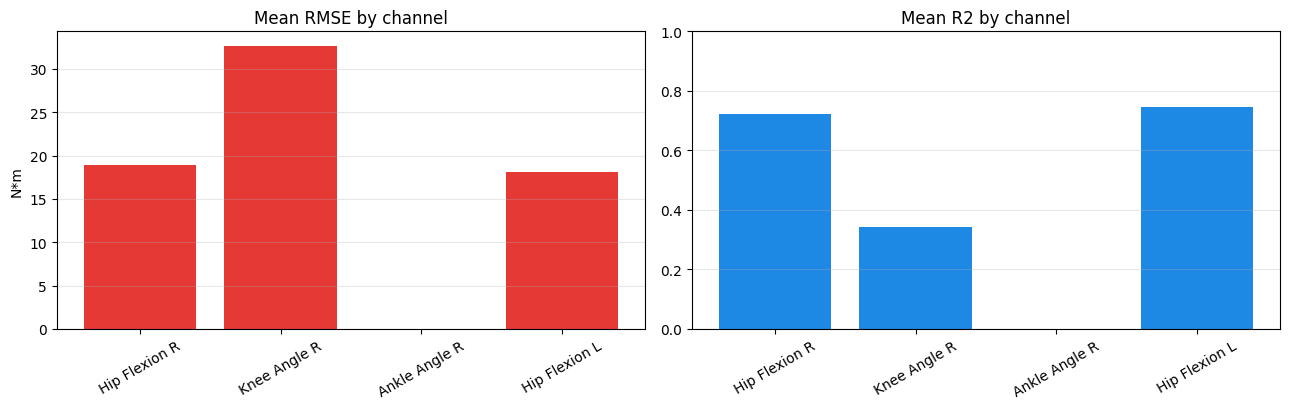

In [ ]:
# Aggregate per-channel metrics across all trials (same spirit as compare notebook quick diagnostics)
agg_rows = []
for c, (key, label) in enumerate(OUTPUT_LABELS):
    vals_rmse = []
    vals_r2 = []
    for d in TRIAL_DATA_ANALYSIS.values():
        m = d["metrics"][c]
        if np.isfinite(m["rmse"]):
            vals_rmse.append(m["rmse"])
        if np.isfinite(m["r2"]):
            vals_r2.append(m["r2"])

    agg_rows.append(
        {
            "channel_key": key,
            "channel": label,
            "mean_RMSE [N*m]": float(np.nanmean(vals_rmse)) if vals_rmse else np.nan,
            "mean_R2": float(np.nanmean(vals_r2)) if vals_r2 else np.nan,
            "n_trials": max(len(vals_rmse), len(vals_r2)),
        }
    )

DF_CHANNEL_AGG = pd.DataFrame(agg_rows)
display(DF_CHANNEL_AGG)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(DF_CHANNEL_AGG["channel"], DF_CHANNEL_AGG["mean_RMSE [N*m]"], color="#E53935")
ax[0].set_title("Mean RMSE by channel")
ax[0].set_ylabel("N*m")
ax[0].tick_params(axis="x", rotation=30)
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(DF_CHANNEL_AGG["channel"], DF_CHANNEL_AGG["mean_R2"], color="#1E88E5")
ax[1].set_title("Mean R2 by channel")
ax[1].set_ylim(0.0, 1.0)
ax[1].tick_params(axis="x", rotation=30)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

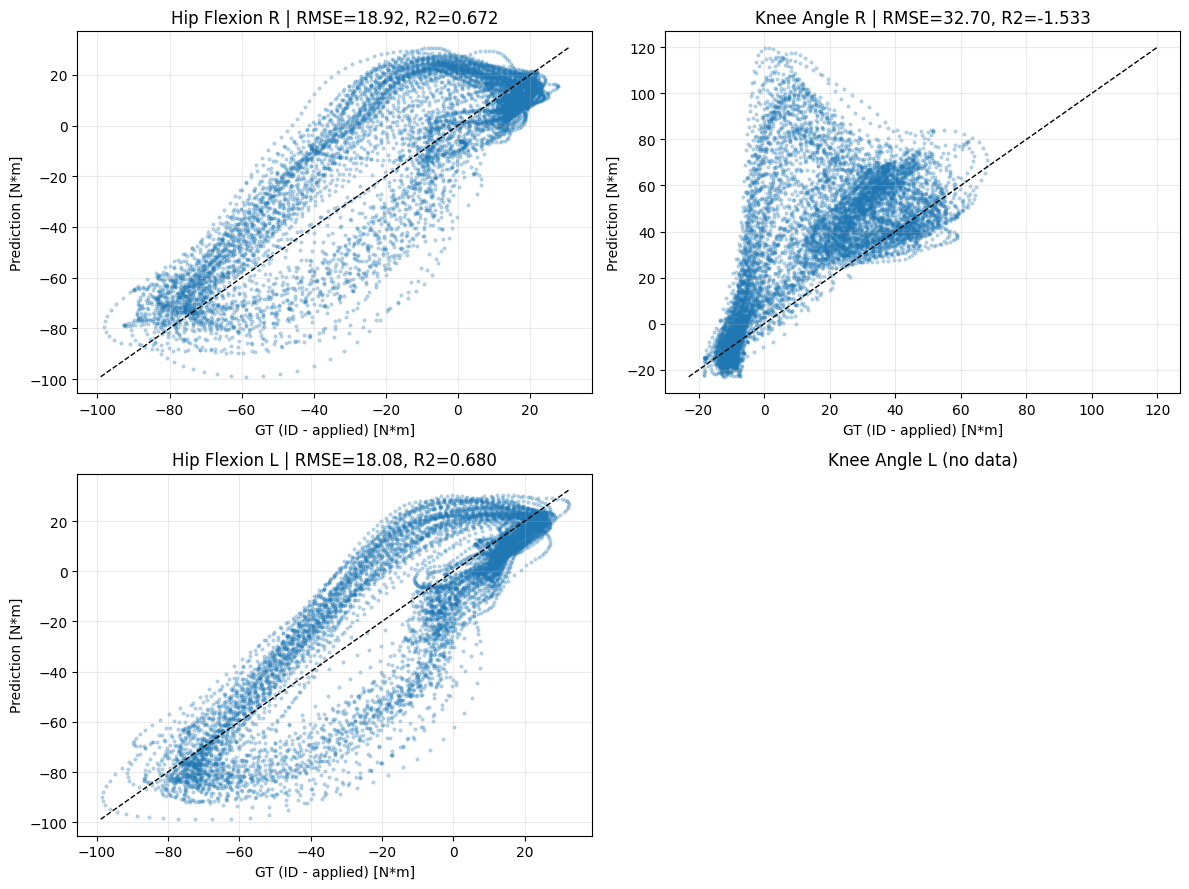

In [ ]:
# Scatter view across all valid samples (prediction vs GT) for channels with predictions
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
plot_channels = [0, 1, 3, 4]  # hip/knee R/L most relevant for exo trials

for ax, c in zip(axes, plot_channels):
    xs = []
    ys = []
    for d in TRIAL_DATA_ANALYSIS.values():
        p = d["pred_nm"][:, c]
        g = d["id_nm"][:, c]
        v = np.isfinite(p) & np.isfinite(g)
        if v.any():
            xs.append(g[v])
            ys.append(p[v])

    if not xs:
        ax.set_title(f"{OUTPUT_LABELS[c][1]} (no data)")
        ax.axis("off")
        continue

    x = np.concatenate(xs)
    y = np.concatenate(ys)
    rmse, r2 = rmse_and_r2(x, y)

    ax.scatter(x, y, s=4, alpha=0.25)
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.0)
    ax.set_xlabel("GT (ID - applied) [N*m]")
    ax.set_ylabel("Prediction [N*m]")
    ax.set_title(f"{OUTPUT_LABELS[c][1]} | RMSE={rmse:.2f}, R2={r2:.3f}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()